# EDA for Columns V and ID
In Kaggle's Fraud competition, we used Alijs's great EDA here for the original 53 columns and first 95 V columns. He did not include the remaining 244 V columns nor the ID columns, so we made the following kernel to analyze the missing V and ID columns. We also display correlation between C, D, and M columns.

The V columns appear to be redundant and correlated. Therefore for each block of V columns with similar NAN structure, we could find subsets within the block that are correlated (r > 0.75). Then we can replace the entire block with one column from each subset.

For example in block V1-V11, we see that the subsets [[1],[2,3],[4,5],[6,7],[8,9],[10,11]] exist and we can choose [1, 3, 4, 6, 8, 11] to represent the V1-V11 block without losing that much information. Alternatively you could apply PCA on each block, but this subset reduce method performed better.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np,gc # linear algebra
import pandas as pd

In [2]:
train_transaction = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/data/ieee-fraud-detection/train_transaction.csv')

train_identity = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/data/ieee-fraud-detection/train_identity.csv')

test_transaction = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/data/ieee-fraud-detection/test_transaction.csv')

test_identity = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/data/ieee-fraud-detection/test_identity.csv')

In [3]:
cols_t = ['TransactionID', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9']
cols_v = ['V'+str(x) for x in range(1,340)]; types_v = {}
for c in cols_v: types_v[c] = 'float32'
train = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/data/ieee-fraud-detection/train_transaction.csv',usecols=cols_t+['isFraud']+cols_v,dtype=types_v)

# NAN search
We will search all the columns of train_transaction.csv to determine which columns are related by the number of NANs present. We see that D1 relates to a subset of V281 thru V315, and D11 relates to V1 thru V11. Also we find groups of Vs with similar NAN structure. And we see that M1, M2, M3 related and M8, M9 related.

In [5]:
nans_df = train.isna()
nans_groups={}
i_cols = ['V'+str(i) for i in range(1,340)]
for col in train.columns:
    cur_group = nans_df[col].sum()
    try:
        nans_groups[cur_group].append(col)
    except:
        nans_groups[cur_group]=[col]
del nans_df; x=gc.collect()

for k,v in nans_groups.items():
    print('####### NAN count =',k)
    print(v)

####### NAN count = 0
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']
####### NAN count = 8933
['card2']
####### NAN count = 1565
['card3']
####### NAN count = 1577
['card4']
####### NAN count = 4259
['card5']
####### NAN count = 1571
['card6']
####### NAN count = 65706
['addr1', 'addr2']
####### NAN count = 352271
['dist1']
####### NAN count = 552913
['dist2']
####### NAN count = 94456
['P_emaildomain']
####### NAN count = 453249
['R_emaildomain']
####### NAN count = 1269
['D1', 'V281', 'V282', 'V283', 'V288', 'V289', 'V296', 'V300', 'V301', 'V313', 'V314', 'V315']
####### NAN count = 280797
['D2']
####### NAN count = 262878
['D3']
####### NAN count = 168922
['D4']
####### NAN count = 309841
['D5']
####### NAN count = 517353
['D6']
####### NAN count = 551623
['D7']
####### NAN count = 515614
['D8', 'D9']
####### NAN count = 76022
['D10']
####### NAN count = 27

# V1-V11, D11

In [6]:
Vc = ['dayr','isFraud','TransactionAmt','card1','addr1','D1n','D11n']
Vs = nans_groups[279287]
Vtitle = 'V1 - V11, D11'

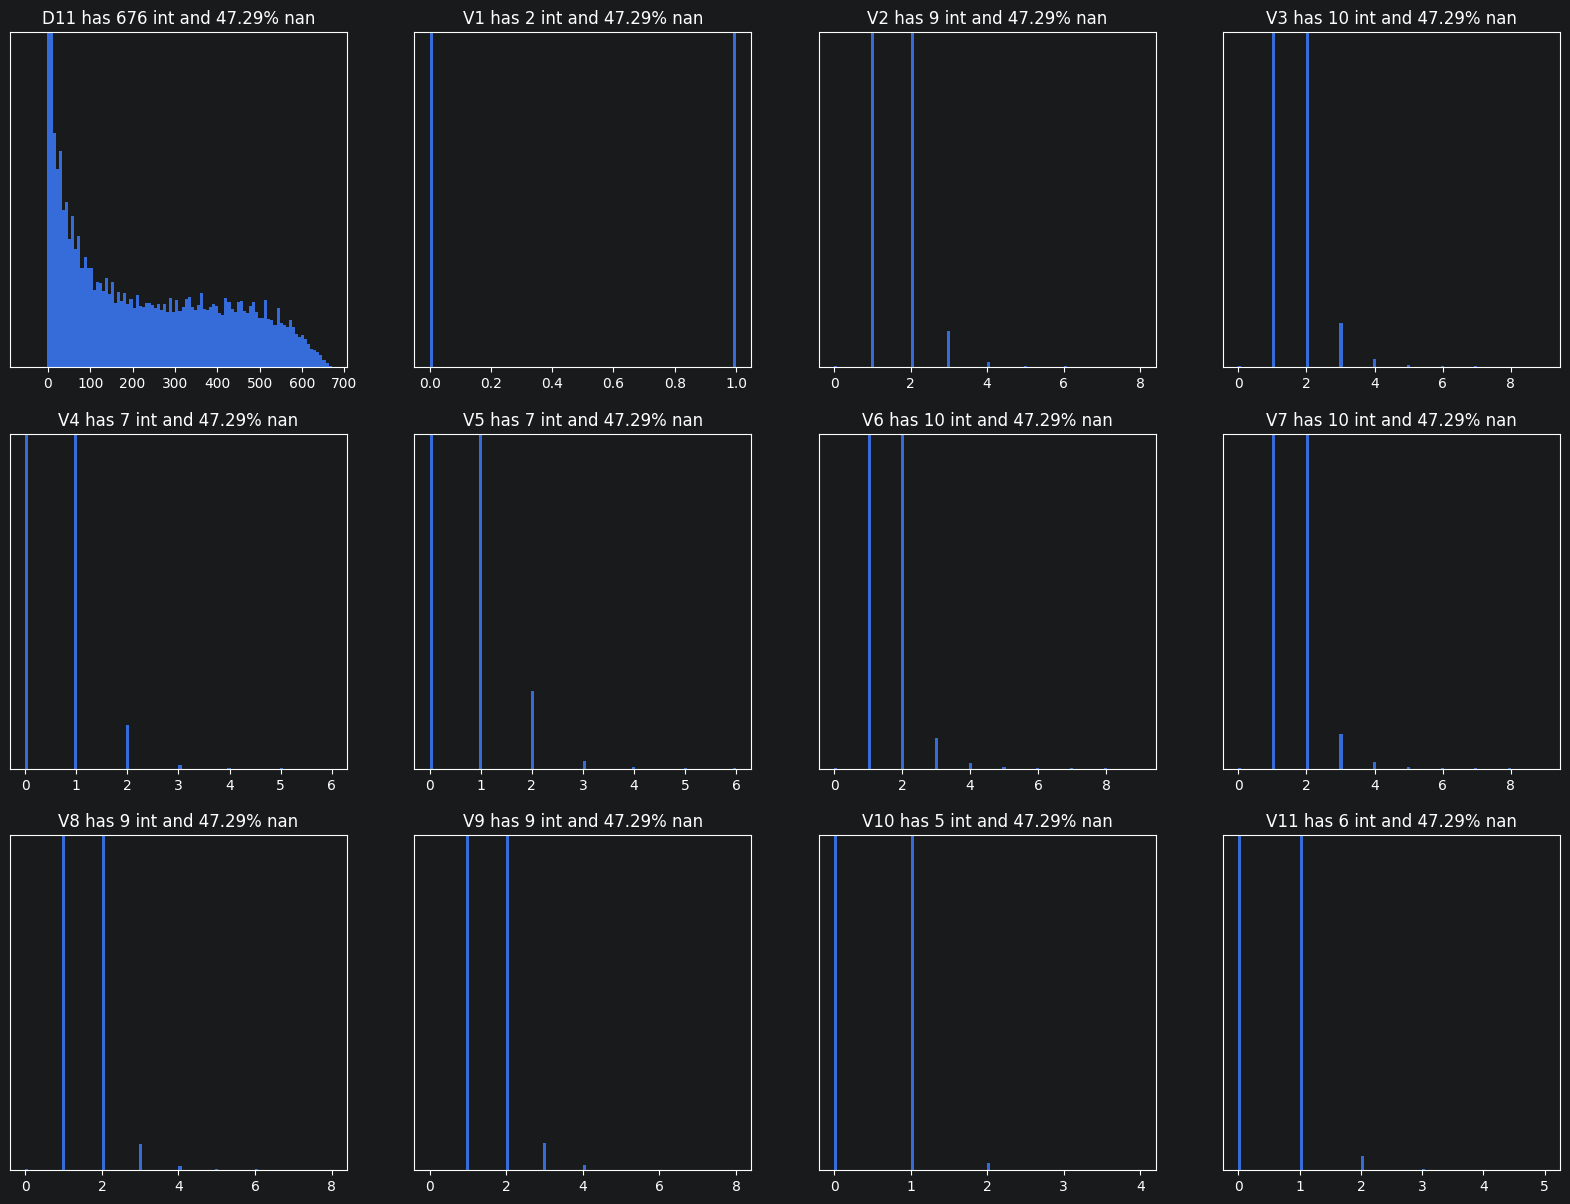

In [7]:
def make_plots(Vs):
    col = 4
    row = len(Vs)//4+1
    plt.figure(figsize=(20,row*5))
    idx = train[~train[Vs[0]].isna()].index
    for i,v in enumerate(Vs):
        plt.subplot(row,col,i+1)
        n = train[v].nunique()
        x = np.sum(train.loc[idx,v]!=train.loc[idx,v].astype(int))
        y = np.round(100*np.sum(train[v].isna())/len(train),2)
        t = 'int'
        if x!=0: t = 'float'
        plt.title(v+' has '+str(n)+' '+t+' and '+str(y)+'% nan')
        plt.yticks([])
        h = plt.hist(train.loc[idx,v],bins=100)
        if len(h[0])>1: plt.ylim((0,np.sort(h[0])[-2]))
    plt.show()
make_plots(Vs)

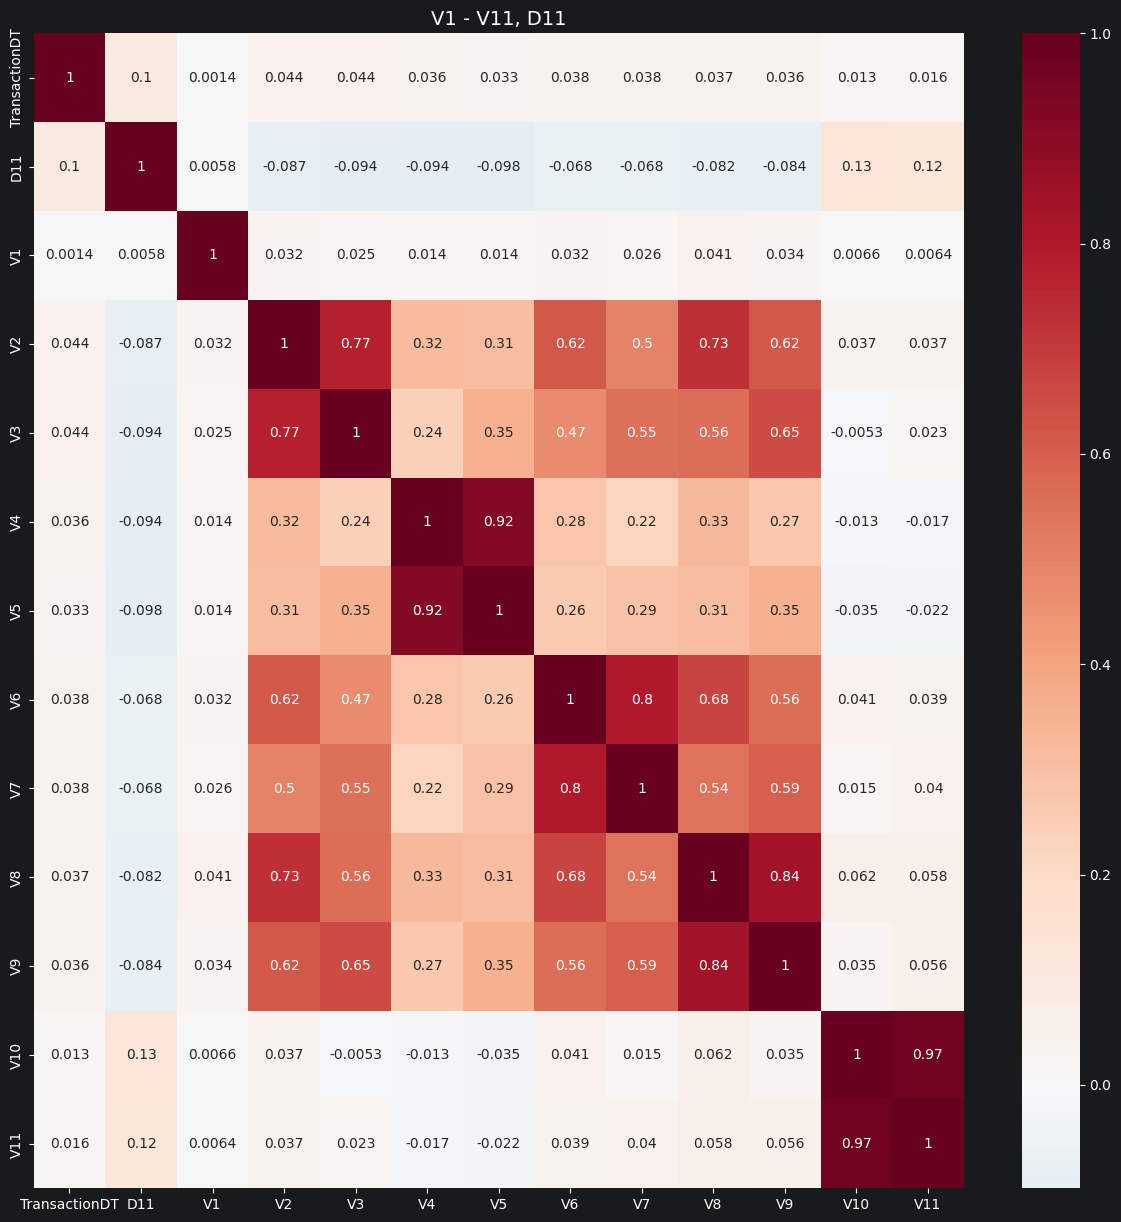

In [8]:
def make_corr(Vs,Vtitle=''):
    cols = ['TransactionDT'] + Vs
    plt.figure(figsize=(15,15))
    sns.heatmap(train[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
    if Vtitle!='': plt.title(Vtitle,fontsize=14)
    else: plt.title(Vs[0]+' - '+Vs[-1],fontsize=14)
    plt.show()
make_corr(Vs,Vtitle)

In [9]:
grps = [[1],[2,3],[4,5],[6,7],[8,9],[10,11]]
def reduce_group(grps,c='V'):
    use = []
    for g in grps:
        mx = 0; vx = g[0]
        for gg in g:
            n = train[c+str(gg)].nunique()
            if n>mx:
                mx = n
                vx = gg
            #print(str(gg)+'-'+str(n),', ',end='')
        use.append(vx)
        #print()
    print('Use these',use)
reduce_group(grps)

Use these [1, 3, 4, 6, 8, 11]
